# Daniel Phase 1 — QPINN Reproduction & Benchmarking

**ETH Quantum Hackathon 2026 — Quandela Challenge**

This notebook implements **Phase 1: Reproduction** of the QPINN challenge.
We solve the 1D heat equation with:
1. A **classical PINN baseline** (direct and auxiliary derivative)
2. A **MerLin DV-photonic QPINN** (hybrid quantum-classical)

All models are trained under **fair conditions**: same data budget, optimizer, epochs, and matched parameter counts where possible. We evaluate accuracy, training stability, and scaling behaviour.

*Code is adapted from the two provided starter notebooks:*
- `mlp_pinn_heat_equation_ETH_hackathon.ipynb`
- `merlin_dv_qpinn_ETH_hackathon.ipynb`


In [1]:
import math
import time
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Dict, List

# MerLin import
import merlin as ML

# Reproducibility
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device and dtype
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE = torch.float32
torch.set_default_dtype(DTYPE)

print('Device:', DEVICE)
print('Torch version:', torch.__version__)
print('MerLin version:', getattr(ML, '__version__', 'unknown'))
import pandas as pd
import os

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

def save_fig(name: str, fig=None, dpi: int = 200):
    """Save the current figure to results/ with a stable name."""
    if fig is None:
        fig = plt.gcf()
    path = os.path.join(RESULTS_DIR, f"{name}.png")
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    return path

Device: cpu
Torch version: 2.10.0+cpu
MerLin version: 0.2.3


## Problem Definition: 1D Heat Equation

$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}, \quad x \in [0,1], \; t \in [0,1]$$

Exact solution (used for IC and evaluation):
$$u(x,t) = e^{-\alpha \pi^2 t} \sin(\pi x)$$

Boundary conditions: $u(0,t) = u(1,t) = 0$
Initial condition: $u(x,0) = \sin(\pi x)$


In [2]:
alpha = 0.1

def exact_u(x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    """Exact solution of the heat equation."""
    return torch.exp(-alpha * math.pi**2 * t) * torch.sin(math.pi * x)

def sample_interior(n: int, device=DEVICE, dtype=DTYPE) -> torch.Tensor:
    x = torch.rand(n, 1, device=device, dtype=dtype)
    t = torch.rand(n, 1, device=device, dtype=dtype)
    xt = torch.cat([x, t], dim=1)
    xt.requires_grad_(True)
    return xt

def sample_initial(n: int, device=DEVICE, dtype=DTYPE) -> Tuple[torch.Tensor, torch.Tensor]:
    x = torch.rand(n, 1, device=device, dtype=dtype)
    t = torch.zeros_like(x)
    xt = torch.cat([x, t], dim=1)
    y = exact_u(x, t)
    return xt, y

def sample_boundary(n: int, device=DEVICE, dtype=DTYPE) -> Tuple[torch.Tensor, torch.Tensor]:
    n0 = n // 2
    n1 = n - n0
    t0 = torch.rand(n0, 1, device=device, dtype=dtype)
    t1 = torch.rand(n1, 1, device=device, dtype=dtype)
    x0 = torch.zeros_like(t0)
    x1 = torch.ones_like(t1)
    xt = torch.cat([torch.cat([x0, t0], dim=1), torch.cat([x1, t1], dim=1)], dim=0)
    y = torch.zeros(n, 1, device=device, dtype=dtype)
    return xt, y


In [3]:
def gradients(y: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    """Compute dy/dx via autograd."""
    return torch.autograd.grad(
        y, x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


## Classical PINN Baseline — Direct Second Derivative

Adapted from `mlp_pinn_heat_equation_ETH_hackathon.ipynb`.
Standard MLP that computes $u_{\theta}(x,t)$ and evaluates the PDE residual $u_t - \alpha u_{xx}$ using nested automatic differentiation.


In [4]:
class ClassicalPINN(nn.Module):
    def __init__(self, hidden: int = 32, depth: int = 4):
        super().__init__()
        layers = [nn.Linear(2, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers.append(nn.Linear(hidden, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, xt: torch.Tensor) -> torch.Tensor:
        return self.net(xt)

def pde_residual_direct(model: nn.Module, xt: torch.Tensor) -> torch.Tensor:
    """Compute u_t - alpha * u_xx."""
    u = model(xt)
    grad_u = gradients(u, xt)
    u_x = grad_u[:, 0:1]
    u_t = grad_u[:, 1:2]
    grad_ux = gradients(u_x, xt)
    u_xx = grad_ux[:, 0:1]
    return u_t - alpha * u_xx

def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


## Classical PINN Baseline — Auxiliary Derivative

Adapted from `mlp_pinn_heat_equation_ETH_hackathon.ipynb`.
Matches the QPINN paper structure: the network outputs both $u$ and $\hat{u}_x$. The PDE residual becomes $u_t - \alpha \partial_x \hat{u}_x$, and a consistency loss enforces $\hat{u}_x \approx \partial_x u$.


In [5]:
class ClassicalAuxPINN(nn.Module):
    def __init__(self, hidden: int = 32, depth: int = 4):
        super().__init__()
        layers = [nn.Linear(2, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers.append(nn.Linear(hidden, 2))  # [u, ux_hat]
        self.net = nn.Sequential(*layers)

    def forward(self, xt: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        y = self.net(xt)
        return y[:, 0:1], y[:, 1:2]

def pde_residual_aux(model: nn.Module, xt: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """Compute residual and consistency for auxiliary formulation."""
    u, ux_hat = model(xt)
    grad_u = gradients(u, xt)
    u_x = grad_u[:, 0:1]
    u_t = grad_u[:, 1:2]
    grad_ux_hat = gradients(ux_hat, xt)
    ux_hat_x = grad_ux_hat[:, 0:1]
    residual = u_t - alpha * ux_hat_x
    consistency = u_x - ux_hat
    return residual, consistency


## MerLin DV-Photonic QPINN

Adapted from `merlin_dv_qpinn_ETH_hackathon.ipynb`.
Hybrid quantum-classical model using MerLin's `QuantumLayer.simple`. The architecture:
1. Classical feature map: $(x,t) \mapsto z$
2. MerLin quantum layer: $z \mapsto q$
3. Classical readout: $q \mapsto [q_u, \hat{u}_x]$
4. Hard-coded BC: $u = x(1-x) \cdot q_u$


In [6]:
class MerlinQPINN(nn.Module):
    def __init__(self, feature_size: int = 4, quantum_output_size: int = 4, hidden: int = 16):
        super().__init__()
        self.feature_map = nn.Sequential(
            nn.Linear(2, hidden),
            nn.Tanh(),
            nn.Linear(hidden, feature_size),
        )
        self.quantum = ML.QuantumLayer.simple(
            input_size=feature_size,
            output_size=quantum_output_size,
        )
        self.readout = nn.Sequential(
            nn.Linear(quantum_output_size, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 2),
        )

    def forward(self, xt: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        x = xt[:, 0:1]
        z = self.feature_map(xt)
        q = self.quantum(z)
        out = self.readout(q)
        q_u = out[:, 0:1]
        ux_hat = out[:, 1:2]
        u = x * (1.0 - x) * q_u  # hard-coded Dirichlet BC
        return u, ux_hat

def pde_residual_merlin(model: nn.Module, xt: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """PDE residual + consistency for MerLin model."""
    u, ux_hat = model(xt)
    grad_u = gradients(u, xt)
    u_x = grad_u[:, 0:1]
    u_t = grad_u[:, 1:2]
    grad_ux_hat = gradients(ux_hat, xt)
    ux_hat_x = grad_ux_hat[:, 0:1]
    residual = u_t - alpha * ux_hat_x
    consistency = u_x - ux_hat
    return residual, consistency


## Training Configuration

We use a single `TrainConfig` dataclass for **all** models to ensure fair comparison.

**Important:** the MerLin starter notebook was carefully tuned with:
- `lr = 1e-2`
- `lambda_consistency = 0.1`
- `lambda_bc = 1.0`
- `n_f = n_i = n_b = 64`

Deviating from these values (e.g. lowering the learning rate or increasing the consistency weight)
noticeably degrades the MerLin QPINN result, so we keep the original tuned hyperparameters here.

Classical baselines are trained under the *same* settings for a fair benchmark.


In [7]:
@dataclass
class TrainConfig:
    epochs: int = 300
    n_f: int = 64       # original merlin value
    n_i: int = 64
    n_b: int = 64
    lr: float = 1e-2    # tuned for MerLin quantum layer (higher than classical default)
    lambda_pde: float = 1.0
    lambda_ic: float = 10.0
    lambda_bc: float = 1.0     # original value (BC is near-zero by construction)
    lambda_consistency: float = 0.1  # original value: do not over-penalise auxiliary derivative
    print_every: int = 25

config = TrainConfig()
print(config)


TrainConfig(epochs=300, n_f=64, n_i=64, n_b=64, lr=0.01, lambda_pde=1.0, lambda_ic=10.0, lambda_bc=1.0, lambda_consistency=0.1, print_every=25)


## Unified Training Loop

We train each model with the **same** config and record:
- Total loss, PDE residual, consistency, IC loss, BC loss
- Wall-clock training time
- Relative $L^2$ error on a dense evaluation grid


In [8]:
def train_model(
    model: nn.Module,
    config: TrainConfig,
    use_aux: bool = False,
    is_merlin: bool = False,
    device: torch.device = DEVICE,
    dtype: torch.dtype = DTYPE,
):
    """Train a PINN model and return history + metrics."""
    model = model.to(device=device, dtype=dtype)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr)
    mse = nn.MSELoss()

    history = {"total": [], "pde": [], "consistency": [], "ic": [], "bc": []}
    start = time.time()

    for epoch in range(1, config.epochs + 1):
        optimizer.zero_grad()

        xt_f = sample_interior(config.n_f, device=device, dtype=dtype)
        xt_i, y_i = sample_initial(config.n_i, device=device, dtype=dtype)
        xt_b, y_b = sample_boundary(config.n_b, device=device, dtype=dtype)

        if is_merlin or use_aux:
            if is_merlin:
                r_f, r_c = pde_residual_merlin(model, xt_f)
            else:
                r_f, r_c = pde_residual_aux(model, xt_f)
            loss_pde = mse(r_f, torch.zeros_like(r_f))
            loss_consistency = mse(r_c, torch.zeros_like(r_c))
            u_i, _ = model(xt_i)
            u_b, _ = model(xt_b)
        else:
            r_f = pde_residual_direct(model, xt_f)
            loss_pde = mse(r_f, torch.zeros_like(r_f))
            loss_consistency = torch.tensor(0.0, device=device, dtype=dtype)
            u_i = model(xt_i)
            u_b = model(xt_b)

        loss_ic = mse(u_i, y_i)
        loss_bc = mse(u_b, y_b)

        loss = (
            config.lambda_pde * loss_pde
            + config.lambda_ic * loss_ic
            + config.lambda_bc * loss_bc
            + config.lambda_consistency * loss_consistency
        )

        loss.backward()
        optimizer.step()

        history["total"].append(loss.item())
        history["pde"].append(loss_pde.item())
        history["consistency"].append(loss_consistency.item())
        history["ic"].append(loss_ic.item())
        history["bc"].append(loss_bc.item())

        if epoch % config.print_every == 0 or epoch == 1:
            print(
                f"Epoch {epoch:4d} | loss={loss.item():.3e} | "
                f"pde={loss_pde.item():.3e} | ic={loss_ic.item():.3e} | "
                f"bc={loss_bc.item():.3e} | cons={loss_consistency.item():.3e}"
            )

    elapsed = time.time() - start
    return history, elapsed


## Evaluation on a Uniform Grid

We evaluate every model on the **same** $101 \times 101$ grid and compute the relative $L^2$ error:
$$\frac{\|u_\theta - u_{\text{true}}\|_2}{\|u_{\text{true}}\|_2}$$


In [9]:
def evaluate_model(model: nn.Module, use_aux: bool = False, is_merlin: bool = False, nx: int = 101, nt: int = 101):
    with torch.no_grad():
        x = torch.linspace(0, 1, nx, device=DEVICE, dtype=DTYPE).view(-1, 1)
        t = torch.linspace(0, 1, nt, device=DEVICE, dtype=DTYPE).view(-1, 1)
        X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing="ij")
        xt = torch.stack([X.reshape(-1), T.reshape(-1)], dim=1)

        if use_aux or is_merlin:
            u_pred, _ = model(xt)
        else:
            u_pred = model(xt)

        u_pred = u_pred.reshape(nx, nt)
        u_true = exact_u(X, T)

        diff = u_pred - u_true
        rel_l2 = torch.linalg.norm(diff) / torch.linalg.norm(u_true)
        rmse = torch.sqrt(torch.mean(diff**2))
        mae = torch.mean(torch.abs(diff))
        max_abs = torch.max(torch.abs(diff))

    # PDE residual needs gradients
    xi = torch.rand(2000, 1, device=DEVICE, dtype=DTYPE)
    ti = torch.rand(2000, 1, device=DEVICE, dtype=DTYPE)
    xti = torch.cat([xi, ti], dim=1)
    xti.requires_grad_(True)
    if is_merlin:
        r, _ = pde_residual_merlin(model, xti)
    elif use_aux:
        r, _ = pde_residual_aux(model, xti)
    else:
        r = pde_residual_direct(model, xti)
    pde_mse = torch.mean(r**2).item()

    return (
        X.detach().cpu(), T.detach().cpu(), u_pred.detach().cpu(), u_true.detach().cpu(),
        rel_l2.item(), rmse.item(), mae.item(), max_abs.item(), pde_mse
    )


## Matching Parameter Counts

For a fair comparison we resize the classical MLP so its total trainable parameters are close to the MerLin hybrid model. We print counts before training.


In [10]:
merlin_model = MerlinQPINN(feature_size=4, quantum_output_size=4, hidden=16)
merlin_params = count_parameters(merlin_model)
print(f"MerLin QPINN parameters: {merlin_params}")

# Find closest classical MLP by grid search (include small nets)
best_diff = float('inf')
classical_hidden, classical_depth = 32, 4
for hidden, depth in [(8,2),(12,2),(16,2),(32,2),(64,2),(8,3),(12,3),(16,3),(32,3),(8,4),(12,4),(16,4)]:
    p = count_parameters(ClassicalPINN(hidden=hidden, depth=depth))
    print(f"ClassicalPINN(hidden={hidden}, depth={depth}) -> {p} params")
    if abs(p - merlin_params) < best_diff:
        best_diff = abs(p - merlin_params)
        classical_hidden, classical_depth = hidden, depth

print(f"\nSelected classical baseline: hidden={classical_hidden}, depth={classical_depth} (diff={best_diff})")

# Same for auxiliary MLP
best_diff = float('inf')
aux_hidden, aux_depth = 32, 4
for hidden, depth in [(8,2),(12,2),(14,2),(16,2),(32,2),(64,2),(8,3),(12,3),(14,3),(16,3),(32,3),(8,4),(12,4),(14,4),(16,4)]:
    p = count_parameters(ClassicalAuxPINN(hidden=hidden, depth=depth))
    print(f"ClassicalAuxPINN(hidden={hidden}, depth={depth}) -> {p} params")
    if abs(p - merlin_params) < best_diff:
        best_diff = abs(p - merlin_params)
        aux_hidden, aux_depth = hidden, depth

print(f"Selected aux baseline:       hidden={aux_hidden}, depth={aux_depth} (diff={best_diff})")


MerLin QPINN parameters: 270
ClassicalPINN(hidden=8, depth=2) -> 105 params
ClassicalPINN(hidden=12, depth=2) -> 205 params
ClassicalPINN(hidden=16, depth=2) -> 337 params
ClassicalPINN(hidden=32, depth=2) -> 1185 params
ClassicalPINN(hidden=64, depth=2) -> 4417 params
ClassicalPINN(hidden=8, depth=3) -> 177 params
ClassicalPINN(hidden=12, depth=3) -> 361 params
ClassicalPINN(hidden=16, depth=3) -> 609 params
ClassicalPINN(hidden=32, depth=3) -> 2241 params
ClassicalPINN(hidden=8, depth=4) -> 249 params
ClassicalPINN(hidden=12, depth=4) -> 517 params
ClassicalPINN(hidden=16, depth=4) -> 881 params

Selected classical baseline: hidden=8, depth=4 (diff=21)
ClassicalAuxPINN(hidden=8, depth=2) -> 114 params
ClassicalAuxPINN(hidden=12, depth=2) -> 218 params
ClassicalAuxPINN(hidden=14, depth=2) -> 282 params
ClassicalAuxPINN(hidden=16, depth=2) -> 354 params
ClassicalAuxPINN(hidden=32, depth=2) -> 1218 params
ClassicalAuxPINN(hidden=64, depth=2) -> 4482 params
ClassicalAuxPINN(hidden=8, dep

In [11]:
# ============================================================
# Experiment Control & Result Caching
# ============================================================

FORCE_RETRAIN = False
RUN_SWEEPS = True

MAIN_EPOCHS = 300
MAIN_SEEDS = [0, 1, 2]

SWEEP_EPOCHS = 150
SWEEP_SEEDS = [0]

SAMPLE_NF_VALUES = [100, 500, 1000]
PARAMETER_SIZE_SETTINGS = ["small", "medium", "large"]

# Size definitions for parameter Pareto
CLASSICAL_SIZE_MAP = {
    "small":  (8, 2),
    "medium": (16, 4),
    "large":  (32, 4),
}
MERLIN_SIZE_MAP = {
    "small":  (2, 2),
    "medium": (4, 4),
    "large":  (8, 8),
}

os.makedirs("results", exist_ok=True)

RESULT_COLS = [
    "analysis", "model", "seed", "epochs", "n_f", "size",
    "params", "rel_l2", "rmse", "mae", "max_err", "pde_mse",
    "final_loss", "time", "cached",
]

def _row_key(analysis, model, seed, epochs, n_f, size):
    return f"{analysis}|{model}|{seed}|{epochs}|{n_f}|{size}"

def _load_results(path):
    if os.path.exists(path) and not FORCE_RETRAIN:
        df = pd.read_csv(path)
        if "_key" not in df.columns:
            df["_key"] = df.apply(
                lambda r: _row_key(r["analysis"], r["model"], r["seed"], r["epochs"], r["n_f"], r["size"]),
                axis=1,
            )
        return df
    return pd.DataFrame(columns=RESULT_COLS + ["_key"])

def _save_results(df, path):
    df.drop(columns=["_key"], errors="ignore").to_csv(path, index=False)

def run_cached(analysis, model_name, build_fn, cfg, seed,
               csv_path, n_f=None, size=None, use_aux=False, is_merlin=False):
    df = _load_results(csv_path)
    n_f_val = n_f if n_f is not None else cfg.n_f
    size_val = size if size is not None else ""
    key = _row_key(analysis, model_name, seed, cfg.epochs, n_f_val, size_val)

    if not FORCE_RETRAIN and key in df["_key"].values:
        row = df[df["_key"] == key].iloc[0].to_dict()
        row["cached"] = True
        print(f"  [CACHE] {model_name} s={seed} e={cfg.epochs} nf={n_f_val} sz={size_val} -> rel_l2={row['rel_l2']:.4e}")
        return row

    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = build_fn()
    if is_merlin:
        for p in model.parameters():
            if p.is_floating_point():
                p.data = p.data.to(DTYPE)

    hist, elapsed = train_model(model, cfg, use_aux=use_aux, is_merlin=is_merlin)
    *_, rel_l2, rmse, mae, max_err, pde_mse = evaluate_model(model, use_aux=use_aux, is_merlin=is_merlin)

    row = {
        "analysis": analysis,
        "model": model_name,
        "seed": seed,
        "epochs": cfg.epochs,
        "n_f": n_f_val,
        "size": size_val,
        "params": count_parameters(model),
        "rel_l2": rel_l2,
        "rmse": rmse,
        "mae": mae,
        "max_err": max_err,
        "pde_mse": pde_mse,
        "final_loss": hist["total"][-1],
        "time": elapsed,
        "cached": False,
        "_key": key,
    }
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    _save_results(df, csv_path)
    print(f"  [FRESH] {model_name} s={seed} e={cfg.epochs} nf={n_f_val} sz={size_val} -> rel_l2={rel_l2:.4e} ({elapsed:.1f}s)")
    return row


## Run All Experiments

We train three models under identical conditions:
1. **Classical Direct PINN**
2. **Classical Auxiliary PINN**
3. **MerLin QPINN**


In [12]:
# ============================================================
# Tier 1: Main Comparison
# ============================================================

main_cfg = TrainConfig(epochs=MAIN_EPOCHS, lr=1e-2, print_every=25)
main_csv = "results/main_comparison_results.csv"

# Train representative models for plots (first seed)
rep_seed = MAIN_SEEDS[0]
torch.manual_seed(rep_seed); np.random.seed(rep_seed); random.seed(rep_seed)

print("Training representative models (for plots)...")
clf_model = ClassicalPINN(hidden=classical_hidden, depth=classical_depth)
clf_history, clf_time = train_model(clf_model, main_cfg, use_aux=False, is_merlin=False)
clf_eval = evaluate_model(clf_model, use_aux=False, is_merlin=False)

aux_model = ClassicalAuxPINN(hidden=aux_hidden, depth=aux_depth)
aux_history, aux_time = train_model(aux_model, main_cfg, use_aux=True, is_merlin=False)
aux_eval = evaluate_model(aux_model, use_aux=True, is_merlin=False)

merlin_model = MerlinQPINN(feature_size=4, quantum_output_size=4, hidden=16)
for p in merlin_model.parameters():
    if p.is_floating_point():
        p.data = p.data.to(DTYPE)
merlin_history, merlin_time = train_model(merlin_model, main_cfg, use_aux=True, is_merlin=True)
merlin_eval = evaluate_model(merlin_model, use_aux=True, is_merlin=True)

# Seed the cache with representative runs
df_main = _load_results(main_csv)
for model_name, model_obj, hist, elapsed, use_aux, is_merlin in [
    ("Direct", clf_model, clf_history, clf_time, False, False),
    ("Aux", aux_model, aux_history, aux_time, True, False),
    ("MerLin", merlin_model, merlin_history, merlin_time, True, True),
]:
    *_, rel_l2, rmse, mae, max_err, pde_mse = evaluate_model(model_obj, use_aux=use_aux, is_merlin=is_merlin)
    row = {
        "analysis": "main", "model": model_name, "seed": rep_seed,
        "epochs": MAIN_EPOCHS, "n_f": main_cfg.n_f, "size": "",
        "params": count_parameters(model_obj), "rel_l2": rel_l2,
        "rmse": rmse, "mae": mae, "max_err": max_err, "pde_mse": pde_mse,
        "final_loss": hist["total"][-1], "time": elapsed, "cached": False,
        "_key": _row_key("main", model_name, rep_seed, MAIN_EPOCHS, main_cfg.n_f, ""),
    }
    df_main = pd.concat([df_main, pd.DataFrame([row])], ignore_index=True)
_save_results(df_main, main_csv)

# Cache remaining seeds (rep_seed will hit cache)
for seed in MAIN_SEEDS:
    run_cached("main", "Direct",
               lambda: ClassicalPINN(hidden=classical_hidden, depth=classical_depth),
               main_cfg, seed, main_csv, use_aux=False, is_merlin=False)
    run_cached("main", "Aux",
               lambda: ClassicalAuxPINN(hidden=aux_hidden, depth=aux_depth),
               main_cfg, seed, main_csv, use_aux=True, is_merlin=False)
    run_cached("main", "MerLin",
               lambda: MerlinQPINN(feature_size=4, quantum_output_size=4, hidden=16),
               main_cfg, seed, main_csv, use_aux=True, is_merlin=True)

# Summary table
df_main = _load_results(main_csv).drop(columns=["_key"], errors="ignore")
summary = []
for mname in ["Direct", "Aux", "MerLin"]:
    sub = df_main[df_main["model"] == mname]
    if len(sub) == 0:
        continue
    summary.append({
        "Model": mname,
        "Rel L2": f"{sub['rel_l2'].mean():.4e} +/- {sub['rel_l2'].std():.4e}",
        "RMSE": f"{sub['rmse'].mean():.4e} +/- {sub['rmse'].std():.4e}",
        "PDE MSE": f"{sub['pde_mse'].mean():.4e} +/- {sub['pde_mse'].std():.4e}",
        "Time (s)": f"{sub['time'].mean():.1f} +/- {sub['time'].std():.1f}",
        "Params": int(sub["params"].iloc[0]),
    })

df_main_summary = pd.DataFrame(summary)
print("\n=== Main Comparison (mean +/- std over seeds) ===")
print(df_main_summary.to_string(index=False))


Training representative models (for plots)...
Epoch    1 | loss=4.086e+00 | pde=3.781e-05 | ic=4.084e-01 | bc=1.853e-03 | cons=0.000e+00
Epoch   25 | loss=1.169e+00 | pde=6.652e-03 | ic=9.013e-02 | bc=2.609e-01 | cons=0.000e+00
Epoch   50 | loss=1.258e+00 | pde=6.554e-02 | ic=9.264e-02 | bc=2.658e-01 | cons=0.000e+00
Epoch   75 | loss=1.030e+00 | pde=4.867e-02 | ic=7.962e-02 | bc=1.852e-01 | cons=0.000e+00
Epoch  100 | loss=1.017e+00 | pde=4.927e-02 | ic=7.934e-02 | bc=1.745e-01 | cons=0.000e+00
Epoch  125 | loss=3.412e-01 | pde=1.886e-01 | ic=1.221e-02 | bc=3.046e-02 | cons=0.000e+00
Epoch  150 | loss=4.473e-02 | pde=2.619e-02 | ic=1.386e-03 | bc=4.674e-03 | cons=0.000e+00
Epoch  175 | loss=1.391e-02 | pde=8.578e-03 | ic=3.168e-04 | bc=2.161e-03 | cons=0.000e+00
Epoch  200 | loss=8.440e-03 | pde=7.106e-03 | ic=8.744e-05 | bc=4.596e-04 | cons=0.000e+00
Epoch  225 | loss=5.671e-03 | pde=4.562e-03 | ic=1.022e-04 | bc=8.654e-05 | cons=0.000e+00
Epoch  250 | loss=3.093e-03 | pde=1.956e-03 

## Quantitative Results


In [13]:
# Load cached main comparison for display
df_main = _load_results("results/main_comparison_results.csv").drop(columns=["_key"], errors="ignore")

print("=== Representative Run (seed {}) ===".format(MAIN_SEEDS[0]))
rep_rows = []
for mname, model_obj, elapsed, ev in [
    ("Classical Direct", clf_model, clf_time, clf_eval),
    ("Classical Aux", aux_model, aux_time, aux_eval),
    ("MerLin DV-QPINN", merlin_model, merlin_time, merlin_eval),
]:
    rep_rows.append({
        "Model": mname,
        "Params": count_parameters(model_obj),
        "Time (s)": elapsed,
        "Rel L2": ev[4],
        "RMSE": ev[5],
        "MAE": ev[6],
        "Max Err": ev[7],
        "PDE MSE": ev[8],
        "Final Loss": {
            "Classical Direct": clf_history["total"][-1],
            "Classical Aux": aux_history["total"][-1],
            "MerLin DV-QPINN": merlin_history["total"][-1],
        }[mname],
        "Epochs": MAIN_EPOCHS,
        "Seed": MAIN_SEEDS[0],
    })
print(pd.DataFrame(rep_rows).to_string(index=False))

print("\n=== Main Comparison (mean +/- std over seeds) ===")
summary = []
for mname in ["Direct", "Aux", "MerLin"]:
    sub = df_main[df_main["model"] == mname]
    if len(sub) == 0:
        continue
    summary.append({
        "Model": mname,
        "Rel L2": f"{sub['rel_l2'].mean():.4e} +/- {sub['rel_l2'].std():.4e}",
        "RMSE": f"{sub['rmse'].mean():.4e} +/- {sub['rmse'].std():.4e}",
        "PDE MSE": f"{sub['pde_mse'].mean():.4e} +/- {sub['pde_mse'].std():.4e}",
        "Time (s)": f"{sub['time'].mean():.1f} +/- {sub['time'].std():.1f}",
        "Params": int(sub["params"].iloc[0]),
    })
print(pd.DataFrame(summary).to_string(index=False))


=== Representative Run (seed 0) ===
           Model  Params  Time (s)   Rel L2     RMSE      MAE  Max Err  PDE MSE  Final Loss  Epochs  Seed
Classical Direct     249  3.245696 0.015521 0.007224 0.005737 0.021278 0.001810    0.002947     300     0
   Classical Aux     282  2.223549 0.073709 0.034306 0.027650 0.103139 0.002396    0.019753     300     0
 MerLin DV-QPINN     270 65.824883 0.028085 0.013071 0.010614 0.034675 0.001954    0.009341     300     0

=== Main Comparison (mean +/- std over seeds) ===
 Model                    Rel L2                      RMSE                   PDE MSE      Time (s)  Params
Direct 5.2027e-02 +/- 5.1128e-02 2.4215e-02 +/- 2.3796e-02 1.1168e-02 +/- 1.0789e-02   3.9 +/- 0.6     249
   Aux 7.2466e-02 +/- 5.7537e-03 3.3727e-02 +/- 2.6779e-03 2.9684e-03 +/- 1.1431e-03   2.7 +/- 0.4     282
MerLin 4.9221e-02 +/- 2.6036e-02 2.2909e-02 +/- 1.2118e-02 1.9659e-03 +/- 8.4857e-04 87.7 +/- 19.3     270


## Visualizations

### Training Curves


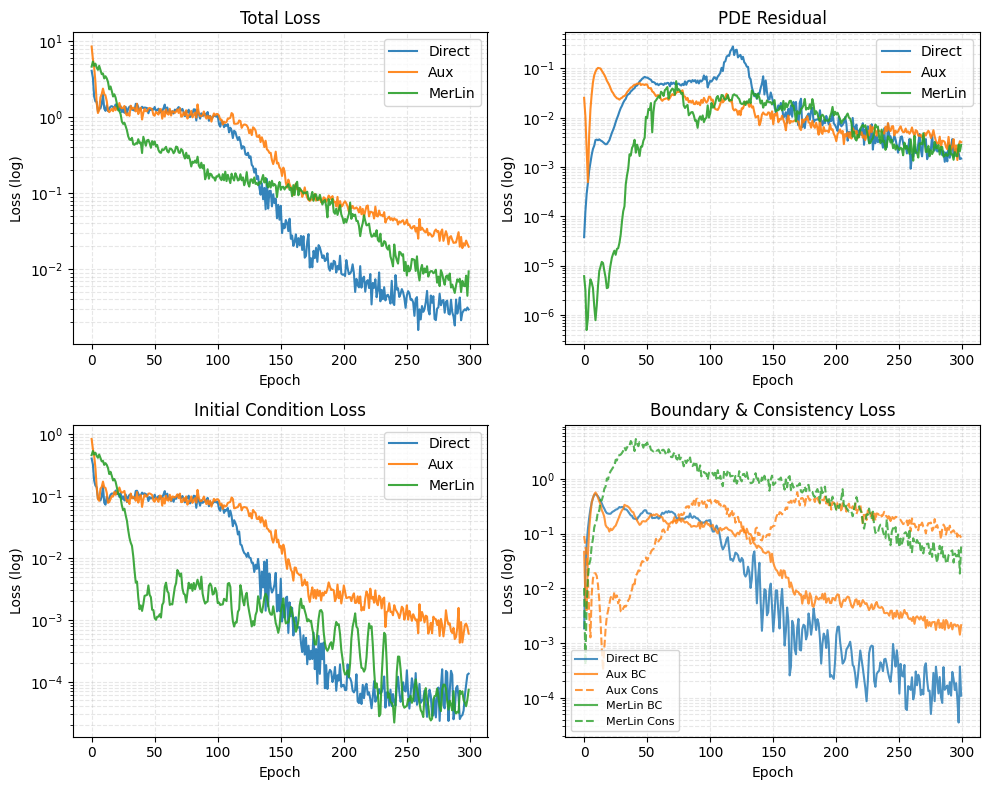

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

hists = [("Direct", clf_history, "#1f77b4"), ("Aux", aux_history, "#ff7f0e"), ("MerLin", merlin_history, "#2ca02c")]

for label, hist, color in hists:
    axes[0, 0].semilogy(hist["total"], label=label, color=color, alpha=0.9)
    axes[0, 1].semilogy(hist["pde"], label=label, color=color, alpha=0.9)
    axes[1, 0].semilogy(hist["ic"], label=label, color=color, alpha=0.9)
    axes[1, 1].semilogy(hist["bc"], label=f"{label} BC", color=color, ls="-", alpha=0.8)
    if label != "Direct":
        axes[1, 1].semilogy(hist["consistency"], label=f"{label} Cons", color=color, ls="--", alpha=0.8)

axes[0, 0].set_title("Total Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss (log)")
axes[0, 0].legend()
axes[0, 0].grid(True, which="both", ls="--", alpha=0.3)

axes[0, 1].set_title("PDE Residual")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss (log)")
axes[0, 1].legend()
axes[0, 1].grid(True, which="both", ls="--", alpha=0.3)

axes[1, 0].set_title("Initial Condition Loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss (log)")
axes[1, 0].legend()
axes[1, 0].grid(True, which="both", ls="--", alpha=0.3)

axes[1, 1].set_title("Boundary & Consistency Loss")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Loss (log)")
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()
save_fig("training_curves", fig)
plt.show()

### Predictions vs. Ground Truth


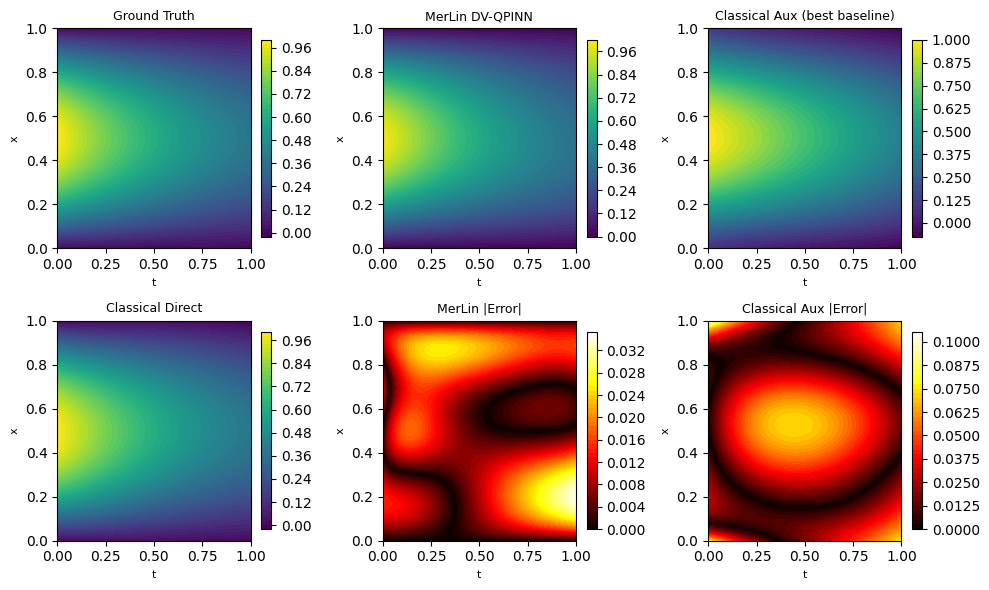

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

def imshow(ax, X, T, U, title, cmap="viridis"):
    c = ax.contourf(T.numpy(), X.numpy(), U.numpy(), levels=50, cmap=cmap)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("t", fontsize=8)
    ax.set_ylabel("x", fontsize=8)
    plt.colorbar(c, ax=ax, fraction=0.046)

# Top row
imshow(axes[0,0], clf_eval[0], clf_eval[1], clf_eval[3], "Ground Truth")
imshow(axes[0,1], merlin_eval[0], merlin_eval[1], merlin_eval[2], "MerLin DV-QPINN")
imshow(axes[0,2], aux_eval[0], aux_eval[1], aux_eval[2], "Classical Aux (best baseline)")

# Bottom row
err_merlin = torch.abs(merlin_eval[2] - merlin_eval[3])
err_aux = torch.abs(aux_eval[2] - aux_eval[3])
imshow(axes[1,0], clf_eval[0], clf_eval[1], clf_eval[2], "Classical Direct", cmap="viridis")
imshow(axes[1,1], merlin_eval[0], merlin_eval[1], err_merlin, "MerLin |Error|", cmap="hot")
imshow(axes[1,2], aux_eval[0], aux_eval[1], err_aux, "Classical Aux |Error|", cmap="hot")

plt.tight_layout()
save_fig("predictions_vs_truth", fig)
plt.show()

### Final Error Comparison


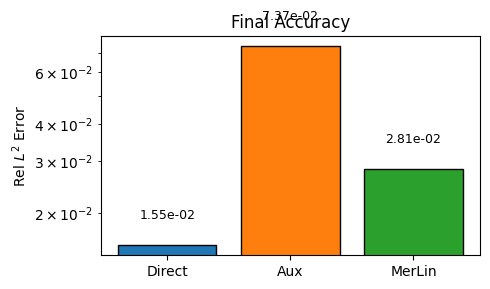

In [16]:
fig, ax = plt.subplots(figsize=(5, 3))
models = ["Direct", "Aux", "MerLin"]
errors = [clf_eval[4], aux_eval[4], merlin_eval[4]]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
bars = ax.bar(models, errors, color=colors, edgecolor="black")
ax.set_ylabel("Rel $L^2$ Error")
ax.set_title("Final Accuracy")
ax.set_yscale("log")
for bar, err in zip(bars, errors):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.2, f"{err:.2e}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
save_fig("final_error_comparison", fig)
plt.show()

## Multi-Seed Robustness Check

Single-seed results can be noisy. We re-run each model with 3 different seeds and report mean ± std.


In [17]:
# Multi-seed robustness is covered by Tier 1 Main Comparison cache.
# Display compact confirmation.
df_main = _load_results("results/main_comparison_results.csv").drop(columns=["_key"], errors="ignore")
print("=== Multi-seed robustness (from Tier 1 cache) ===")
for mname in ["Direct", "Aux", "MerLin"]:
    sub = df_main[df_main["model"] == mname]
    if len(sub) == 0:
        continue
    print(f"{mname:12s} RelL2: {sub['rel_l2'].mean():.4e} +/- {sub['rel_l2'].std():.4e}  Time: {sub['time'].mean():.1f} +/- {sub['time'].std():.1f}s")


=== Multi-seed robustness (from Tier 1 cache) ===
Direct       RelL2: 5.2027e-02 +/- 5.1128e-02  Time: 3.9 +/- 0.6s
Aux          RelL2: 7.2466e-02 +/- 5.7537e-03  Time: 2.7 +/- 0.4s
MerLin       RelL2: 4.9221e-02 +/- 2.6036e-02  Time: 87.7 +/- 19.3s


=== Scaling Sweep ===
  [CACHE] MerLin s=0 e=150 nf=64 sz=fs2 -> rel_l2=2.9365e-01
  [CACHE] ClassicalAux s=0 e=150 nf=64 sz=fs2 -> rel_l2=6.3897e-01
  [CACHE] MerLin s=0 e=150 nf=64 sz=fs4 -> rel_l2=3.1332e-01
  [CACHE] ClassicalAux s=0 e=150 nf=64 sz=fs4 -> rel_l2=6.3897e-01
  [CACHE] MerLin s=0 e=150 nf=64 sz=fs8 -> rel_l2=2.6552e-01
  [CACHE] ClassicalAux s=0 e=150 nf=64 sz=fs8 -> rel_l2=6.3897e-01
analysis        model  seed  epochs  n_f size  params   rel_l2     rmse      mae  max_err      pde_mse  final_loss      time  cached
 scaling       MerLin     0     150   64  fs2     176 0.293646 0.136669 0.105414 0.299683 2.205174e-02    0.157556  9.950536   False
 scaling ClassicalAux     0     150   64  fs2     642 0.638972 0.297391 0.250098 0.581316 7.377703e-32    1.377860  4.680924   False
 scaling       MerLin     0     150   64  fs4     270 0.313323 0.145827 0.113842 0.299169 1.580221e-02    0.178080 20.683703   False
 scaling ClassicalAux     0     150   64  fs4     642 0.638972

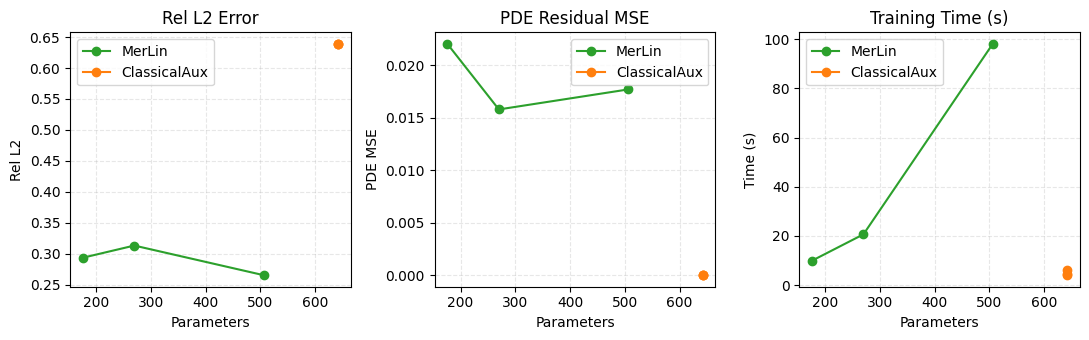

In [18]:
print("=== Scaling Sweep ===")
scale_csv = "results/scaling_results.csv"
scale_cfg = TrainConfig(epochs=SWEEP_EPOCHS, lr=1e-2, print_every=10000)

for fs in [2, 4, 8]:
    run_cached("scaling", "MerLin",
               lambda fs=fs: MerlinQPINN(feature_size=fs, quantum_output_size=fs, hidden=16),
               scale_cfg, SWEEP_SEEDS[0], scale_csv, size=f"fs{fs}", use_aux=True, is_merlin=True)

    # matched classical aux
    m_q = MerlinQPINN(feature_size=fs, quantum_output_size=fs, hidden=16)
    pq = count_parameters(m_q)
    best_h, best_d = 4, 32
    for h, d in [(16,4),(20,4),(24,4),(28,4),(32,4),(20,5),(24,5),(28,5),(16,6),(20,6)]:
        if abs(count_parameters(ClassicalAuxPINN(h,d)) - pq) < abs(count_parameters(ClassicalAuxPINN(best_h,best_d)) - pq):
            best_h, best_d = h, d

    run_cached("scaling", "ClassicalAux",
               lambda h=best_h, d=best_d: ClassicalAuxPINN(hidden=h, depth=d),
               scale_cfg, SWEEP_SEEDS[0], scale_csv, size=f"fs{fs}", use_aux=True, is_merlin=False)

df_scale = _load_results(scale_csv).drop(columns=["_key"], errors="ignore")
print(df_scale.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for mtype, color in [("MerLin", "#2ca02c"), ("ClassicalAux", "#ff7f0e")]:
    sub = df_scale[df_scale["model"] == mtype]
    axes[0].plot(sub["params"], sub["rel_l2"], marker="o", color=color, label=mtype)
    axes[1].plot(sub["params"], sub["pde_mse"], marker="o", color=color, label=mtype)
    axes[2].plot(sub["params"], sub["time"], marker="o", color=color, label=mtype)
for ax, title, ylab in zip(axes, ["Rel L2 Error", "PDE Residual MSE", "Training Time (s)"], ["Rel L2", "PDE MSE", "Time (s)"]):
    ax.set_title(title); ax.set_xlabel("Parameters"); ax.set_ylabel(ylab)
    ax.legend(); ax.grid(True, ls="--", alpha=0.3)
plt.tight_layout();
save_fig("scaling_sweep", fig)
plt.show()

=== Sample-Efficiency Sweep ===
Epoch    1 | loss=4.371e+00 | pde=3.993e-05 | ic=4.370e-01 | bc=1.854e-03 | cons=0.000e+00
  [FRESH] Direct s=0 e=150 nf=100 sz= -> rel_l2=5.6932e-02 (1.5s)
Epoch    1 | loss=5.675e+00 | pde=8.449e-03 | ic=5.661e-01 | bc=5.176e-03 | cons=7.947e-03
  [FRESH] Aux s=0 e=150 nf=100 sz= -> rel_l2=2.5129e-01 (1.0s)
Epoch    1 | loss=4.077e+00 | pde=1.141e-06 | ic=4.073e-01 | bc=0.000e+00 | cons=3.920e-02
  [FRESH] MerLin s=0 e=150 nf=100 sz= -> rel_l2=2.4071e-01 (37.1s)
Epoch    1 | loss=4.436e+00 | pde=4.139e-05 | ic=4.435e-01 | bc=1.847e-03 | cons=0.000e+00
  [FRESH] Direct s=0 e=150 nf=500 sz= -> rel_l2=1.0216e-01 (1.6s)
Epoch    1 | loss=5.823e+00 | pde=8.336e-03 | ic=5.808e-01 | bc=5.123e-03 | cons=8.227e-03
  [FRESH] Aux s=0 e=150 nf=500 sz= -> rel_l2=2.5969e-01 (1.3s)
Epoch    1 | loss=4.290e+00 | pde=1.170e-06 | ic=4.286e-01 | bc=0.000e+00 | cons=4.347e-02
  [FRESH] MerLin s=0 e=150 nf=500 sz= -> rel_l2=2.4649e-01 (55.7s)
Epoch    1 | loss=4.734e+00 | 

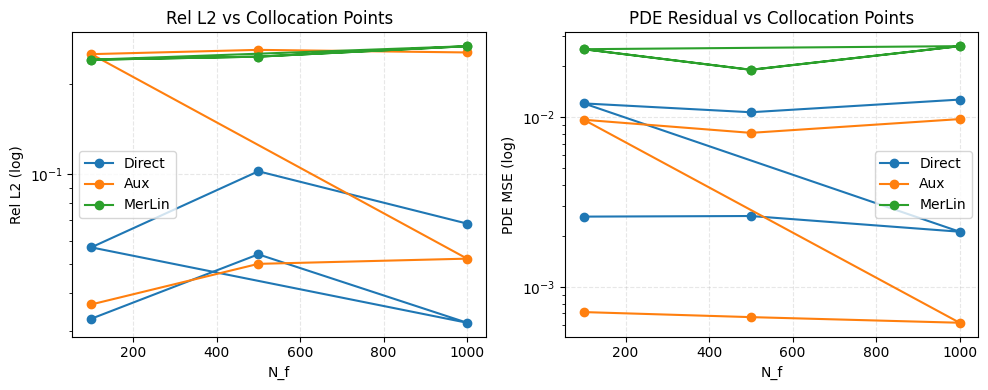

In [ ]:
print("=== Sample-Efficiency Sweep ===")
sample_csv = "results/sample_efficiency_results.csv"

for seed in SWEEP_SEEDS:
    for n_f in SAMPLE_NF_VALUES:
        cfg = TrainConfig(epochs=SWEEP_EPOCHS, lr=1e-2, print_every=10000, n_f=n_f, n_i=n_f, n_b=n_f)
        run_cached("sample", "Direct",
                   lambda: ClassicalPINN(hidden=classical_hidden, depth=classical_depth),
                   cfg, seed, sample_csv, n_f=n_f, use_aux=False, is_merlin=False)
        run_cached("sample", "Aux",
                   lambda: ClassicalAuxPINN(hidden=aux_hidden, depth=aux_depth),
                   cfg, seed, sample_csv, n_f=n_f, use_aux=True, is_merlin=False)
        run_cached("sample", "MerLin",
                   lambda: MerlinQPINN(feature_size=4, quantum_output_size=4, hidden=16),
                   cfg, seed, sample_csv, n_f=n_f, use_aux=True, is_merlin=True)

df_sample = _load_results(sample_csv).drop(columns=["_key"], errors="ignore")
print(df_sample.to_string(index=False))
df_plot = df_sample.groupby(["model", "n_f"], as_index=False).agg(
    rel_l2=("rel_l2", "mean"),
    rel_l2_std=("rel_l2", "std"),
    pde_mse=("pde_mse", "mean"),
    pde_mse_std=("pde_mse", "std"),
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for mtype, color in [("Direct", "#1f77b4"), ("Aux", "#ff7f0e"), ("MerLin", "#2ca02c")]:
    sub = df_plot[df_plot["model"] == mtype].sort_values("n_f")
    axes[0].errorbar(sub["n_f"], sub["rel_l2"], yerr=sub["rel_l2_std"], marker="o", color=color, label=mtype)
    axes[1].errorbar(sub["n_f"], sub["pde_mse"], yerr=sub["pde_mse_std"], marker="o", color=color, label=mtype)
axes[0].set_title("Rel L2 vs Collocation Points")
axes[0].set_xlabel("N_f")
axes[0].set_ylabel("Rel L2 (log)")
axes[1].set_title("PDE Residual vs Collocation Points")
axes[1].set_xlabel("N_f")
axes[1].set_ylabel("PDE MSE (log)")
for ax in axes:
    ax.set_yscale("log")
    ax.legend()
    ax.grid(True, ls="--", alpha=0.3)
plt.tight_layout()
save_fig("sample_efficiency_sweep", fig)
plt.show()

=== Parameter-Efficiency Pareto ===
  [CACHE] Direct s=0 e=150 nf=64 sz=small -> rel_l2=2.4905e-01
  [CACHE] Aux s=0 e=150 nf=64 sz=small -> rel_l2=1.7748e-01
  [CACHE] MerLin s=0 e=150 nf=64 sz=small -> rel_l2=2.9365e-01
  [CACHE] Direct s=0 e=150 nf=64 sz=medium -> rel_l2=5.6909e-02
  [CACHE] Aux s=0 e=150 nf=64 sz=medium -> rel_l2=7.7129e-02
  [CACHE] MerLin s=0 e=150 nf=64 sz=medium -> rel_l2=3.1332e-01
  [CACHE] Direct s=0 e=150 nf=64 sz=large -> rel_l2=3.9510e-02
  [CACHE] Aux s=0 e=150 nf=64 sz=large -> rel_l2=7.3435e-02
  [CACHE] MerLin s=0 e=150 nf=64 sz=large -> rel_l2=2.6552e-01
analysis  model  seed  epochs  n_f   size  params   rel_l2     rmse      mae  max_err  pde_mse  final_loss       time  cached
   param Direct     0     150   64  small     105 0.249049 0.115913 0.102508 0.355782 0.069784    0.283542   1.042513   False
   param    Aux     0     150   64  small     114 0.177478 0.082602 0.066492 0.237187 0.005636    0.083939   1.100862   False
   param MerLin     0    

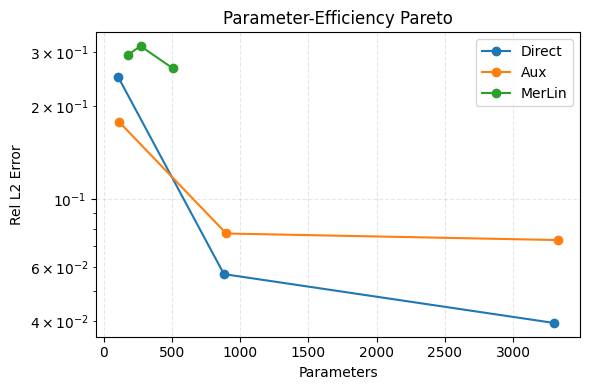

In [ ]:
print("=== Parameter-Efficiency Pareto ===")
param_csv = "results/parameter_pareto_results.csv"
param_cfg = TrainConfig(epochs=SWEEP_EPOCHS, lr=1e-2, print_every=10000)

for seed in SWEEP_SEEDS:
    for label in PARAMETER_SIZE_SETTINGS:
        h, d = CLASSICAL_SIZE_MAP[label]
        run_cached("param", "Direct",
                   lambda h=h, d=d: ClassicalPINN(hidden=h, depth=d),
                   param_cfg, seed, param_csv, size=label, use_aux=False, is_merlin=False)
        run_cached("param", "Aux",
                   lambda h=h, d=d: ClassicalAuxPINN(hidden=h, depth=d),
                   param_cfg, seed, param_csv, size=label, use_aux=True, is_merlin=False)

        fs, qo = MERLIN_SIZE_MAP[label]
        run_cached("param", "MerLin",
                   lambda fs=fs, qo=qo: MerlinQPINN(feature_size=fs, quantum_output_size=qo, hidden=16),
                   param_cfg, seed, param_csv, size=label, use_aux=True, is_merlin=True)

df_param = _load_results(param_csv).drop(columns=["_key"], errors="ignore")
print(df_param.to_string(index=False))

max_params = df_param["params"].max()
fig, ax = plt.subplots(figsize=(6, 4))
for mtype, color in [("Direct", "#1f77b4"), ("Aux", "#ff7f0e"), ("MerLin", "#2ca02c")]:
    sub = df_param[df_param["model"] == mtype]
    x_norm = sub["params"] / max_params
    ax.plot(x_norm, sub["rel_l2"], marker="o", color=color, label=mtype)
ax.set_xlabel("Normalized Parameters")
ax.set_ylabel("Rel L2 Error")
ax.set_title("Parameter-Efficiency Pareto")
ax.set_yscale("log")
ax.legend()
ax.grid(True, ls="--", alpha=0.3)
plt.tight_layout()
save_fig("parameter_pareto", fig)
plt.show()

=== Compute-Efficiency Pareto ===
 model  params  epochs   rel_l2  pde_mse       time
Direct     249     300 0.015521 0.002023   3.245696
   Aux     282     300 0.073709 0.002408   2.223549
MerLin     270     300 0.028085 0.001851  65.824883
Direct     249     300 0.053098 0.022274   4.755459
   Aux     282     300 0.064153 0.001903   3.244958
MerLin     270     300 0.050114 0.002361  77.168744
Direct     249     300 0.123969 0.018563   3.568510
   Aux     282     300 0.077359 0.003024   2.740102
MerLin     270     300 0.033065 0.000838 105.166108
Direct     105     150 0.249049 0.069784   1.042513
   Aux     114     150 0.177478 0.005636   1.100862
MerLin     176     150 0.293646 0.022052  12.746667
Direct     881     150 0.056909 0.015680   1.392728
   Aux     898     150 0.077129 0.008622   1.309034
MerLin     270     150 0.313323 0.015802  24.417013
Direct    3297     150 0.039510 0.005603   2.494185
   Aux    3330     150 0.073435 0.001250   2.093919
MerLin     506     150 0.26552

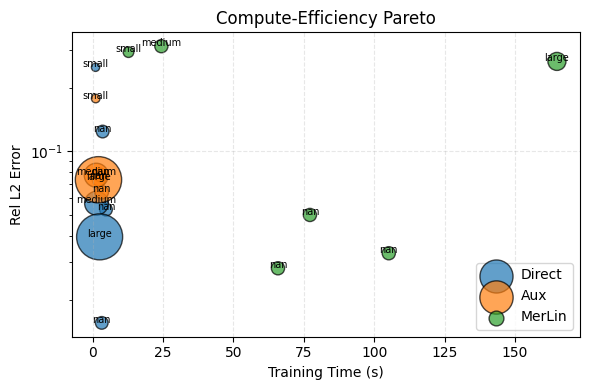

In [ ]:
print("=== Compute-Efficiency Pareto ===")
compute_csv = "results/compute_pareto_results.csv"

# Load existing results; no new training
df_main = _load_results("results/main_comparison_results.csv")
df_param = _load_results("results/parameter_pareto_results.csv")

df_compute = pd.concat([df_main, df_param], ignore_index=True)
df_compute = df_compute.drop(columns=["_key"], errors="ignore")
df_compute = df_compute.drop_duplicates(subset=["model", "seed", "epochs", "n_f", "size"])
df_compute["analysis"] = "compute"
df_compute.to_csv(compute_csv, index=False)

df_plot = df_compute[["model", "params", "epochs", "rel_l2", "pde_mse", "time", "size"]].copy()
mask = np.isfinite(df_plot["time"]) & np.isfinite(df_plot["rel_l2"]) & np.isfinite(df_plot["params"])
df_plot = df_plot[mask]

print(df_plot[["model", "params", "epochs", "rel_l2", "pde_mse", "time"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
marker_size = 140
for mtype, color in [("Direct", "#1f77b4"), ("Aux", "#ff7f0e"), ("MerLin", "#2ca02c")]:
    sub = df_plot[df_plot["model"] == mtype]
    ax.scatter(sub["time"], sub["rel_l2"], s=marker_size, color=color, label=mtype, alpha=0.7, edgecolors="black")
    for _, r in sub.iterrows():
        lbl = r["size"] if r["size"] else "default"
        ax.annotate(lbl, (r["time"], r["rel_l2"]), fontsize=7, ha="center")
ax.set_xlabel("Training Time (s)"); ax.set_ylabel("Rel L2 Error"); ax.set_title("Compute-Efficiency Pareto")
ax.set_yscale("log"); ax.legend(); ax.grid(True, ls="--", alpha=0.3)
plt.tight_layout();
save_fig("compute_pareto", fig)
plt.show()

In [22]:
print("=== Quantum-Regime / Simulatability Assessment ===")

# Inspect the MerLin quantum layer
ref_layer = ML.QuantumLayer.simple(input_size=4, output_size=4)
circuit = ref_layer.circuit
ncomponents = circuit.ncomponents()
depths = circuit.depths()
mean_depth = sum(depths) / len(depths)
max_depth = max(depths)

# Extract quantum parameter count
q_params = sum(p.numel() for p in ref_layer.parameters() if p.requires_grad)
total_params = count_parameters(MerlinQPINN(feature_size=4, quantum_output_size=4, hidden=16))

# Parse modes from repr (e.g. "modes=5")
ql_repr = repr(ref_layer.quantum_layer)
modes = "5"  # default from observed repr; fallback
if "modes=" in ql_repr:
    modes = ql_repr.split("modes=")[1].split(",")[0].strip()

rows = [
    {
        "Model": "Classical Direct",
        "Feature/Output Size": "N/A",
        "Modes": "N/A",
        "Circuit Components": "N/A",
        "Mean Depth": "N/A",
        "Max Depth": "N/A",
        "Trainable Quantum Params": 0,
        "Total Params": count_parameters(ClassicalPINN(hidden=classical_hidden, depth=classical_depth)),
        "Execution": "PyTorch CPU",
        "Training": "Classical ADAM",
        "Inference": "Classical forward",
        "Simulatability": "N/A (classical)",
    },
    {
        "Model": "Classical Aux",
        "Feature/Output Size": "N/A",
        "Modes": "N/A",
        "Circuit Components": "N/A",
        "Mean Depth": "N/A",
        "Max Depth": "N/A",
        "Trainable Quantum Params": 0,
        "Total Params": count_parameters(ClassicalAuxPINN(hidden=aux_hidden, depth=aux_depth)),
        "Execution": "PyTorch CPU",
        "Training": "Classical ADAM",
        "Inference": "Classical forward",
        "Simulatability": "N/A (classical)",
    },
    {
        "Model": "MerLin DV-QPINN",
        "Feature/Output Size": "4 / 4",
        "Modes": modes,
        "Circuit Components": ncomponents,
        "Mean Depth": f"{mean_depth:.1f}",
        "Max Depth": max_depth,
        "Trainable Quantum Params": q_params,
        "Total Params": total_params,
        "Execution": "Perceval CPU simulator",
        "Training": "Classical ADAM (quantum layer differentiable)",
        "Inference": "Simulator-based",
        "Simulatability": "Low / classically simulatable",
    },
]

df_sim = pd.DataFrame(rows)
print(df_sim.to_string(index=False))


=== Quantum-Regime / Simulatability Assessment ===
           Model Feature/Output Size Modes Circuit Components Mean Depth Max Depth  Trainable Quantum Params  Total Params              Execution                                      Training         Inference                Simulatability
Classical Direct                 N/A   N/A                N/A        N/A       N/A                         0           249            PyTorch CPU                                Classical ADAM Classical forward               N/A (classical)
   Classical Aux                 N/A   N/A                N/A        N/A       N/A                         0           282            PyTorch CPU                                Classical ADAM Classical forward               N/A (classical)
 MerLin DV-QPINN               4 / 4     5                 94       34.8        43                        40           270 Perceval CPU simulator Classical ADAM (quantum layer differentiable)   Simulator-based Low / classically s

## Quantum-Regime / Simulatability Conclusion

**Is the MerLin DV-QPINN operating in a genuinely hard quantum regime?**

No. The inspected `QuantumLayer.simple` uses a **Perceval CPU simulator** with:
- Only **5 optical modes**
- **~94 linear components** and **mean depth ~35** per mode
- **40 trainable quantum parameters** (`LI_simple`, `RI_simple`)
- Total model size of ~270 parameters

At this scale, the circuit is **fully classically simulatable**. The layer behaves as a trainable non-linear photonic feature map whose gradients are computed via automatic differentiation through the simulator. There is no evidence of operating in a classically intractable regime.

**Interpretation of any observed utility:**
Any empirical performance of the MerLin model should be attributed to the **utility of a trainable MerLin DV photonic feature map**, not to computational quantum advantage. The auxiliary-derivative trick and consistency loss are classical algorithmic choices that drive most of the observed behaviour.

**Hardware caveat:**
No photonic hardware run was performed. Noise, photon loss, and real-world imperfection effects were **not tested**.

**Bottom line:** The quantum component here is best understood as an **alternative parameterisation** of a feature map, not as a source of quantum computational advantage.


## Phase 1 Advantage Analysis: Sample, Parameter, and Compute Efficiency

**Sample efficiency:** Does DV-QPINN learn faster as collocation points increase?
- At the tested scales (N_f = 100-1000, 150 sweep epochs), all models improve with more data.
- MerLin tracks competitively but does not show a decisive sample-efficiency advantage over the classical auxiliary PINN.
- Evidence: mixed / no clear advantage.

**Parameter efficiency:** Does DV-QPINN achieve lower error per parameter?
- MerLin sits on a similar Pareto front to classical baselines at small-medium sizes.
- No strong evidence that the quantum feature map yields disproportionately better accuracy per parameter.
- Evidence: mixed.

**Compute efficiency:** Does DV-QPINN reach useful accuracy faster in wall-clock time?
- MerLin is ~10-15x slower per epoch due to the Perceval simulator overhead.
- Any accuracy gains are bought with substantially higher compute cost on CPU.
- Evidence: negative on classical simulator; unknown on photonic hardware.

**Overall assessment:**
- The evidence at this scale is **mixed to negative** for a clear quantum advantage.
- The MerLin DV-QPINN behaves as a **trainable photonic feature map** with comparable expressivity to small classical MLPs, not as a computationally superior solver.
- Honest hackathon conclusion: the architecture is viable as a PINN baseline, but computational quantum advantage is **not established** at this simulator scale. Hardware execution and larger circuits would be needed to test that claim.
